In [4]:
import numpy as np
from scipy.optimize import minimize
from IPython.display import clear_output
import time
from tqdm import tqdm
import matplotlib.pyplot as plt

rc = {"font.family" : "Times New Roman", 
      "mathtext.fontset" : "stix"}
plt.rcParams.update(rc)

from QAOA import *
from hamiltonians import *
from heuristics import *
from visualization import *
from analysis import *

import warnings
warnings.filterwarnings("ignore")

### State preparation problem

In [5]:
def training_sp(path,fname,n,H2,coupling_mat,n_iter,tol_lvl,max_restarts=10,eps=1e-3):
    
    # evaluate the exact ground state
    gs = np.min(H2)
    
    # optimize controllable parameters of the ion-native ansatz 
    A_trained, energy, tot_iterations, exec_time, count_restarts, nfev_tot = run_heuristics(n,H2,coupling_mat,n_iter,gs,tol_lvl,max_restarts,eps)
    
    save_training_data_sp(path,fname,n,gs,A_trained,energy,tot_iterations,exec_time,count_restarts,nfev_tot,tol_lvl)
    
def save_training_data_sp(path,fname,n,gs,A_trained,energy,tot_iterations,exec_time,count_restarts,nfev_tot,tol_lvl):
    
    half_energy = energy - gs < tol_lvl*np.abs(gs)
    
    file = path+fname
    with open(file,'w') as fid:
        fid.write("{0:2d}    ".format(n))
        fid.write("{0:8f}    ".format(gs))
        fid.write("{0:8f}    ".format(energy))
        fid.write("{0:1d}    ".format(half_energy))
        fid.write("{0:4d}     ".format(tot_iterations))
        fid.write("{0:8f}     ".format(exec_time))
        fid.write("{0:4d}     ".format(count_restarts))
        fid.write("{0:5d}     ".format(nfev_tot))
        fid.write("{0:4f}\n".format(tol_lvl))

        for i in range(n):
            fid.write("{0:8f}  ".format(A_trained[i]))
        fid.write("\n")
    
    fid.close() 

### Training hyperparameters of the ion native ansatz for a specific system size

In [6]:
# number of qubits
n = 6

# ions chain parameters
nu_rad = 1e6
nu_ax = 0.15e6
mu = 2*np.pi*(nu_rad + 10e3) # in Hz
Omega_max = 2*np.pi*30e3     # in Hz

coupling_mat = radial_coupling_matrix(n, nu_rad, nu_ax, mu, Omega_max) # in kHz

H2 = np.zeros(2**n)
H2[[0,-1]] = 1.0
H2 = 1.0 - H2
e, v = np.linalg.eigh(np.diag(H2))
gs = np.min(e)
emax = np.max(e)
print(gs)

spectrum = np.unique(e)

print(spectrum)

gap = spectrum[1] - spectrum[0]

path = f'state/'
fname = f'{n}q.txt'
fname1 = path + fname

# read simulation parameters
n_iter = 50
max_restarts = 10
eps = 1e-3
tol_lvl = 0.0

np.random.seed(123)
training_sp(path,fname,n,H2,coupling_mat,n_iter,tol_lvl,max_restarts,eps)

0.0
[0. 1.]


### Single-layered energy landscape

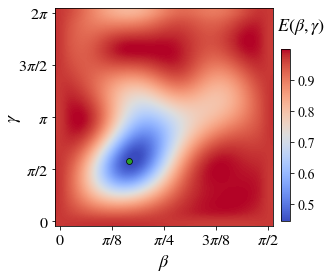

0.443954886967864 0.9997222372167809 [-0.556404 -0.408497 -0.436846 -0.437097 -0.407784 -0.55778 ]


In [7]:
A = np.genfromtxt(fname1,skip_header=1)
H1 = ion_native_hamiltonian(n,A,coupling_mat)
Q = QAOA(1,H1,H2)
landscape = get_landscape(Q,k=25)
plot_landscape(landscape)
print(np.min(landscape),np.max(landscape),A)

### Rescale the hypeparameters to widen the narrow gorge

0.6115234375


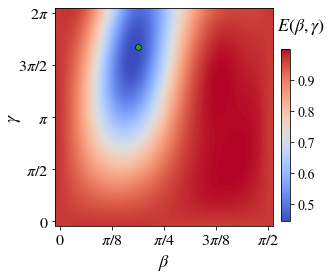

[-0.34025409 -0.24980549 -0.26714157 -0.26729506 -0.24936947 -0.34109554] 6400


In [8]:
A_rescaled, alpha, nfev = rescale_contr_params(n,A,H2,coupling_mat,mu=1.1,k=20,eps=0.05)
print(alpha)

H1_rescaled = ion_native_hamiltonian(n,A_rescaled,coupling_mat)
Q.H1 = H1_rescaled
landscape = get_landscape(Q,k=25)
plot_landscape(landscape)
print(A_rescaled, nfev)

### Single-layered energy for asymmetric $A_j$

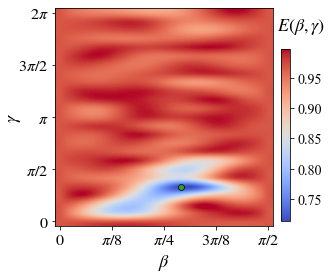

0.7119152634100925


In [9]:
A_asym = np.ones(n)
A_asym[0] = -0.3
H1_asym = ion_native_hamiltonian(n,A_asym,coupling_mat)
Q.H1 = H1_asym
landscape = get_landscape(Q,k=25)
plot_landscape(landscape)
print(np.min(landscape))

### Evaluate the ion-native QAOA performance

### Trained hyperparameters

In [10]:
p_max = 10
n_runs = 10

np.random.seed(12311)

energies, angles, ovlp, r, nfev, exe_time = run_QAOA(H1_rescaled,H2,p_max,method=1,n_runs=10)

pp = np.array(range(1,p_max+1))

data_trained = np.zeros((p_max,3))
data_trained[:,0] = pp
data_trained[:,1] = 1 - r
data_trained[:,2] = ovlp

### Asymmetric hyperparameters

In [13]:
np.random.seed(12551)

energies1, angles1, ovlp1, r1, nfev1, exe_time1 = run_QAOA(H1_asym,H2,p_max,method=1,n_runs=10)

data_asym = np.zeros((p_max,3))
data_asym[:,0] = pp
data_asym[:,1] = 1 - r1
data_asym[:,2] = ovlp1

### Save data

In [14]:
def write_data(fname,p_max,data,angles):
    
    with open(fname,'w') as fid: 
    
        for p in range(p_max):
            fid.write("{0:2d}    ".format(p+1))
            fid.write("{0:8f}    ".format(data[p,0]))
            fid.write("{0:8f}    ".format(data[p,1]))
            fid.write("{0:10f}\n".format(data[p,2]))
            
        for p in range(p_max):
            angles_ = angles[p]
            for i in range(2*(p+1)):
                fid.write("{0:8f}    ".format(angles_[i]))
            fid.write("\n")

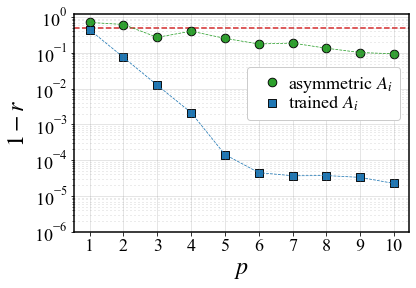

In [15]:
write_data(path+f'{n}q_trained.txt',p_max,data_trained,angles)
write_data(path+f'{n}q_asym.txt',p_max,data_asym,angles1)

data_sets = [data_asym, data_trained]
labels = ['asymmetric $A_i$', 'trained $A_i$']
markers = ['o', 's']
colors = ['tab:green', 'tab:blue']

plot_energies_log(data_sets,labels,markers,colors,-gap/2.0/(gs - emax),1e-6)

### Plot the ground state overlap as a function of the ion native QAOA circuit depth for different system sizes

[ 5  6  7  8  9 10]
[0.636603 0.97417  0.993557 0.997933 0.999566 0.999935 0.999936 0.999959
 0.999999 0.999984]
[0.560977 0.925493 0.987597 0.997871 0.999856 0.999955 0.999963 0.999963
 0.999967 0.999978]
[0.492876 0.849766 0.972957 0.995547 0.999725 0.999906 0.999923 0.999927
 0.999988 0.999943]
[0.446346 0.786938 0.96033  0.99254  0.999155 0.999574 0.999923 0.999927
 0.99993  0.999957]
[0.403692 0.738707 0.945735 0.988709 0.998006 0.999126 0.999713 0.999763
 0.999897 0.999913]
[0.367932 0.713693 0.931072 0.983959 0.996154 0.99841  0.999342 0.999867
 0.999841 0.999893]


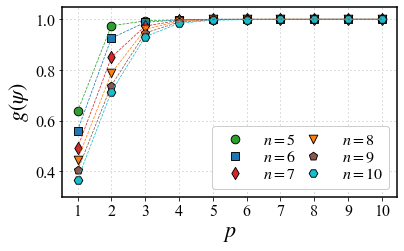

In [16]:
n_start = 5
n_end = 10

data_ovlp_lst = []
labels = []

p_max = 10
ns = np.array(range(n_start,n_end+1))
print(ns)

for i in range(len(ns)):
    
    fname = 'state/'+str(ns[i])+'q_trained.txt'
    data = np.genfromtxt(fname,skip_footer=p_max)
    data_ovlp_lst.append(data)
    
    print(data[:,3])
    
    labels.append(f"$n={ns[i]}$")

markers = ['o', 's', 'd', 'v', 'p', 'H']
colors = ['tab:green', 'tab:blue', 'tab:red', 'tab:orange', 'tab:brown', 'tab:cyan']

plot_ovlp(p_max,data_ovlp_lst,labels,markers,colors,ncol=2,loc=4)